## Settings and imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)


PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

DATA_PATH = config["training_data_path"]
FIGURES_PATH = config["figures_path"]["training"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

## Preprocessing

### Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [4]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [5]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [6]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [7]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [8]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's multiply the values by weights.

In [9]:
inDKs_df = multiply_by_weights(inDKs_df, ELEMENTS_TO_KEEP, weights=MULTIPLICATION_WEIGHTS, suffix='_a')

6. Normalize with respect to Fe and remove Fe.

In [10]:
# inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

### Normalization / taking logarithm

In [11]:
inds_df, inks_df = split_inDKs_df(inDKs_df)

inds_values = transform_data(inds_df, PREPROCESSING_METHOD)
inks_values = transform_data(inks_df, PREPROCESSING_METHOD)

inds_df = pd.DataFrame(inds_values, columns=inds_df.columns)
inks_df = pd.DataFrame(inks_values, columns=inks_df.columns)

inDKs_df = join_to_inDKs_df(inks_df, inds_df, inDKs_df[['Sample_id', 'name']])

In [12]:
inds_df, inks_df = split_inDKs_df(inDKs_df)

mean_df = create_means_df(ELEMENTS_TO_KEEP, inks_df.values, inDKs_df['Sample_id'], np.array([]), pd.Series([]))

In [13]:
# from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

inds_df, inks_df = split_inDKs_df(inDKs_df)

X_pca = pca.fit_transform(inks_df.values)
means_pca = pca.transform(mean_df[ELEMENTS_TO_KEEP])

# tsne = TSNE(n_components=2, random_state=42)
# X_tsne = tsne.fit_transform(inks_df.values)
# means_tsne does not exist, because there is no tsne.transform method!

/home/basia/myvirtualenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


In [14]:
#%matplotlib widget

/home/basia/Documents/atramenty/inks_repo/notebooks/../src/data_utils.py:239: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


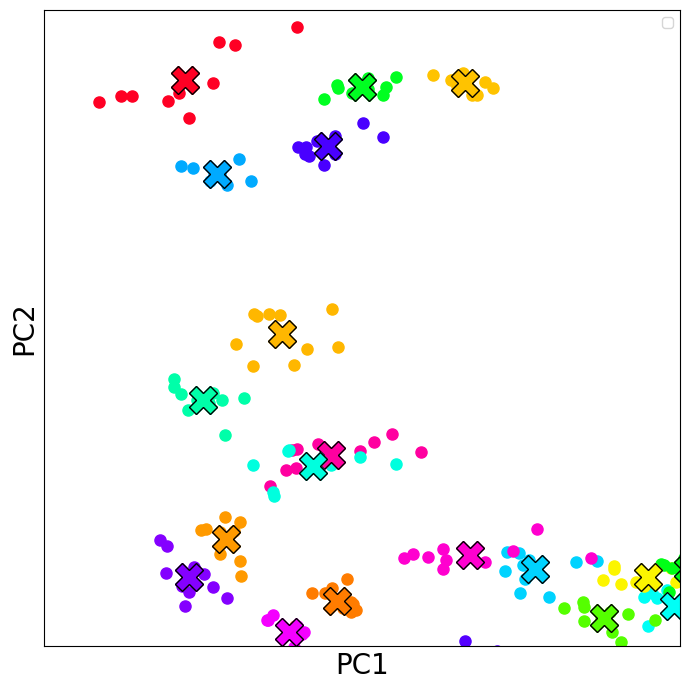

In [15]:
visualise_pca_and_class_means(X_pca, inDKs_df['Sample_id'], 
                                means_pca, mean_df['Sample_id'],
                                x_lower=-4.08, x_upper=0.92,
                                y_lower=2.9, y_upper=7.9,
                                cmap = plt.get_cmap('hsv'),
                                seed=14,
                                path_to_save=FIGURES_PATH + 'PCA_and_class_centers_zoom_14_27_01.png') #421 2 10 14

/home/basia/Documents/atramenty/inks_repo/notebooks/../src/data_utils.py:233: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


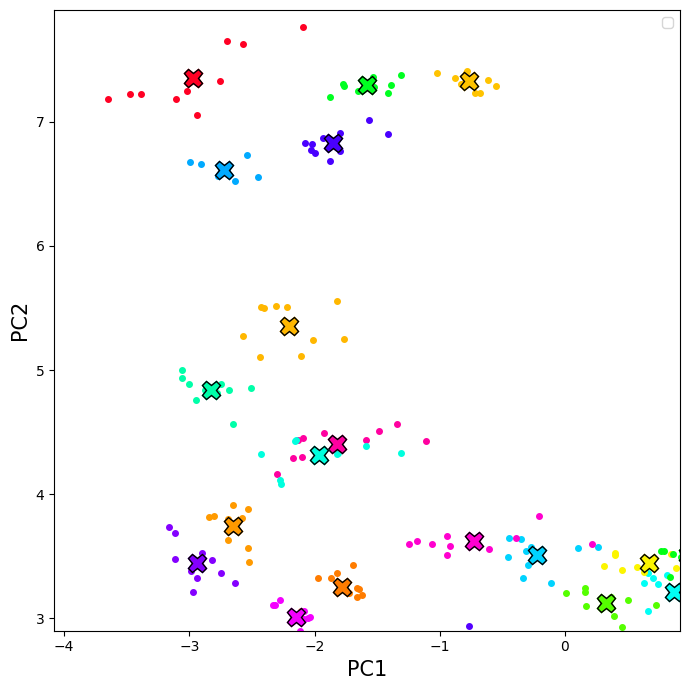

In [15]:
visualise_pca_and_class_means(X_pca, inDKs_df['Sample_id'], 
                                means_pca, mean_df['Sample_id'],
                                x_lower=-4.08, x_upper=0.92,
                                y_lower=2.9, y_upper=7.9,
                                cmap = plt.get_cmap('hsv'),
                                seed=14,
                                path_to_save=FIGURES_PATH + 'PCA_and_class_centers_zoom_14.png') #421 2 10 14

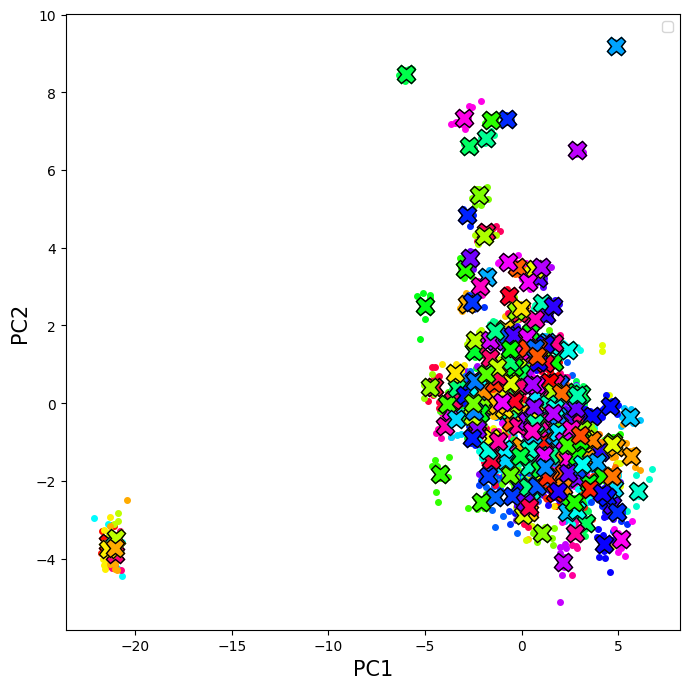

In [16]:
visualise_pca_and_class_means(X_pca, inDKs_df['Sample_id'], 
                                means_pca, mean_df['Sample_id'],
                                x_lower=None, x_upper=None,
                                y_lower=None, y_upper=None,
                                cmap = plt.get_cmap('hsv'),
                                seed=42, #path_to_save=None)
                                path_to_save=FIGURES_PATH + 'PCA_and_class_centers.png')

### Train test split, datasets, dataloaders

In [17]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [18]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(X_y_train, 
                                                                                                               X_y_val, 
                                                                                                               X_y_test, 
                                                                                                               ELEMENTS_TO_KEEP)

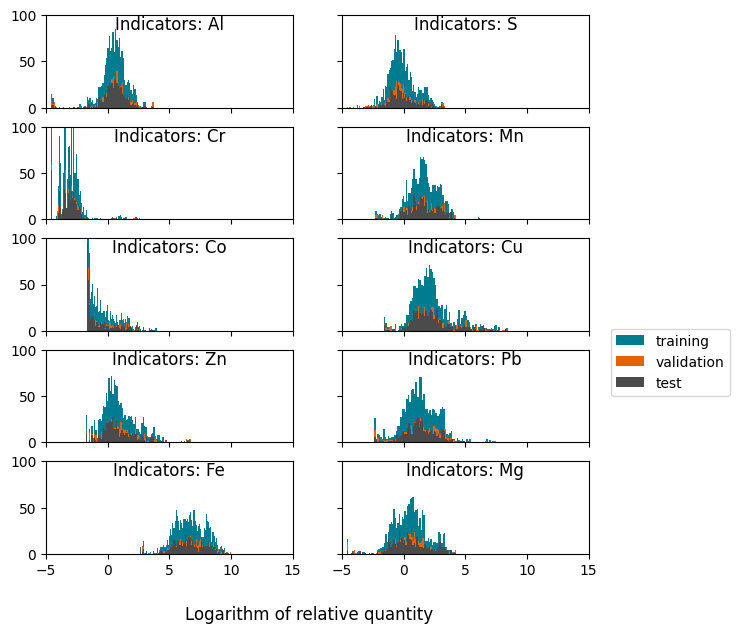

In [19]:
visualise_train_val_test_distributions(X_train, X_val, X_test,
                                        ELEMENTS_TO_KEEP, 
                                        title='Indicators: ',
                                        path_to_save=FIGURES_PATH + 'indicators_train_val_test_histograms.png'
                                        )

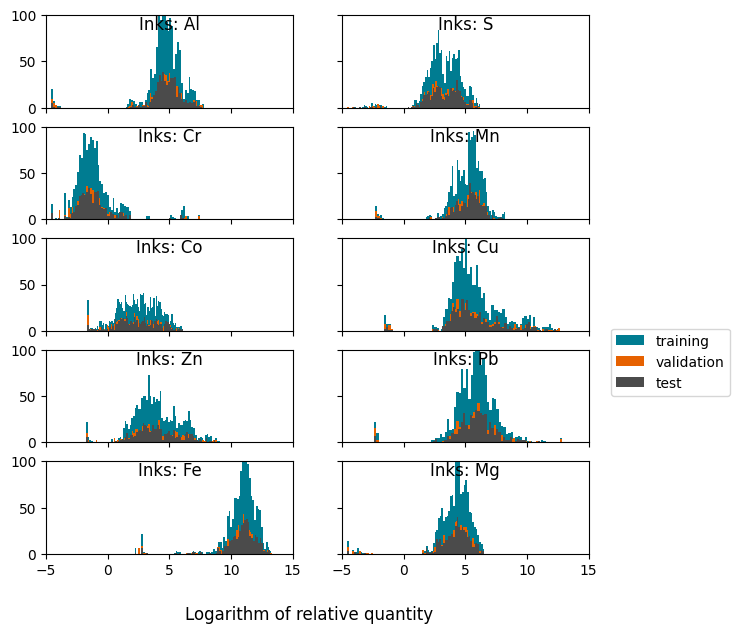

In [20]:
visualise_train_val_test_distributions(y_train, y_val, y_test,
                                        ELEMENTS_TO_KEEP, 
                                        title='Inks: ',
                                        path_to_save='../figures/inks_train_val_test_histograms.png'
                                        )

### Zoom on single element

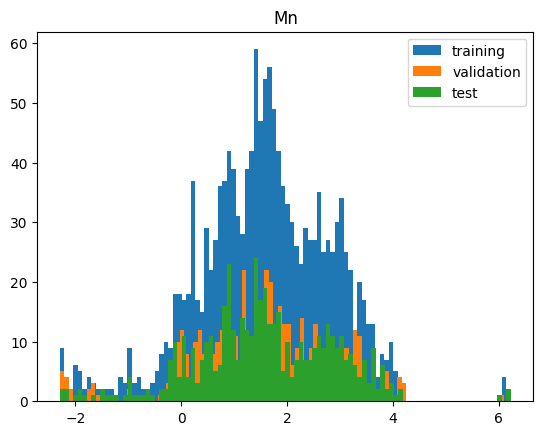

In [22]:
dim = 3
plt.hist(X_train[:,dim], bins=100, label='training');
plt.hist(X_val[:,dim], bins=100, label='validation');
plt.hist(X_test[:,dim], bins=100, label='test');
plt.title(ELEMENTS_TO_KEEP[dim])
plt.legend()